# LGBM & XGBM Comparative Analysis Using Titanic Dataset

# Importing Required Libraries
In this step, all the necessary Python libraries required for data analysis, visualization, preprocessing, model building, and evaluation are imported.

In [12]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Models
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Loading the Dataset
The Titanic dataset is loaded using pandas for further analysis and machine learning operations.

In [13]:
df = pd.read_csv("/content/Titanic_train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Dataset Overview
This section provides basic information about the dataset such as number of rows, columns, data types, and statistical summary.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
df.shape

(891, 12)

In [17]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

# Checking Missing Values
Missing values are identified to understand which features require preprocessing or imputation.

In [18]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [22]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'].fillna(df['Cabin'].mode()[0],inplace=True)

In [23]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [26]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)
Exploratory Data Analysis is performed to understand the distribution of data and relationships between different features.

# Histogram Visualization
Histograms are used to analyze the distribution of numerical features present in the dataset.

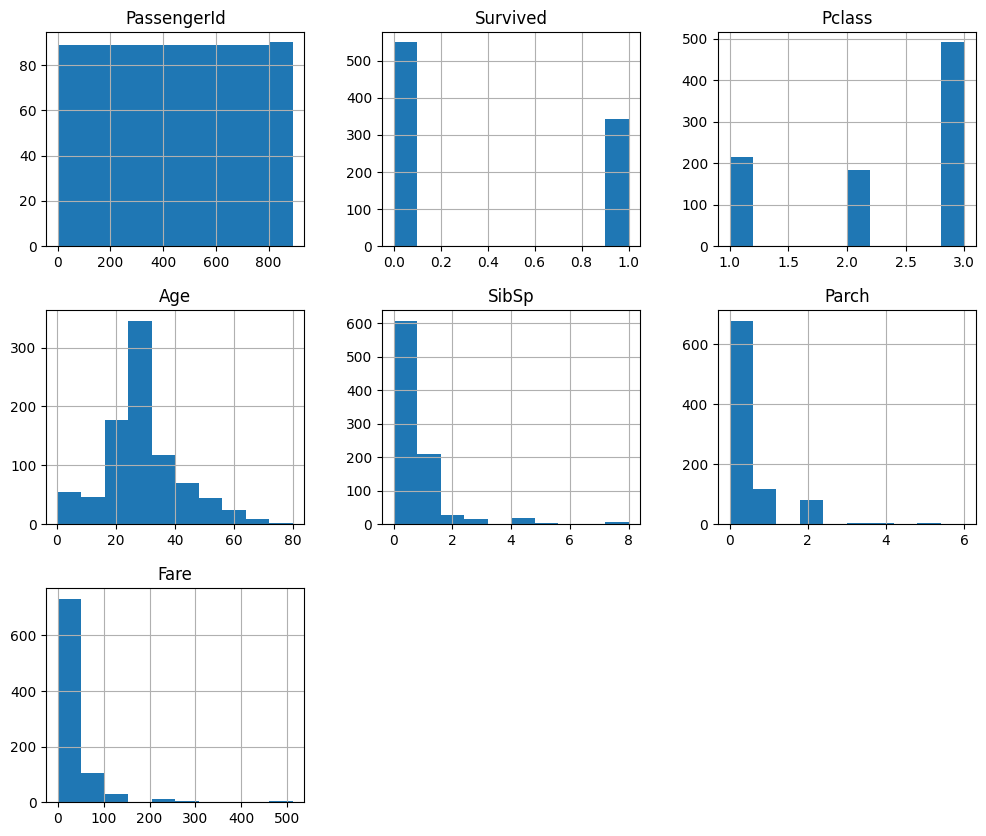

In [27]:
df.hist(figsize=(12,10))
plt.show()

# Box Plot Visualization
Box plots help in identifying outliers and understanding the spread of numerical data.

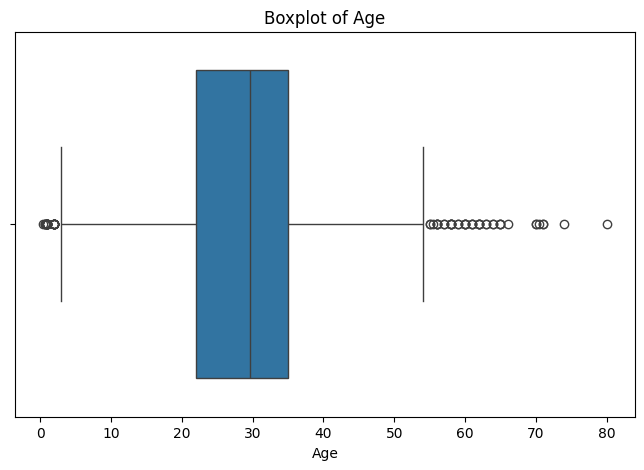

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Age")
plt.show()

# Survival Count Analysis
This visualization shows the number of passengers who survived and those who did not survive.

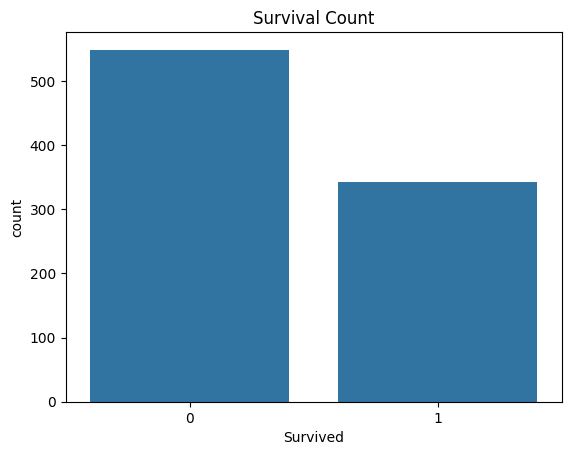

In [29]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

# Passenger Class vs Survival Analysis
This visualization shows the relationship between passenger class and survival probability.

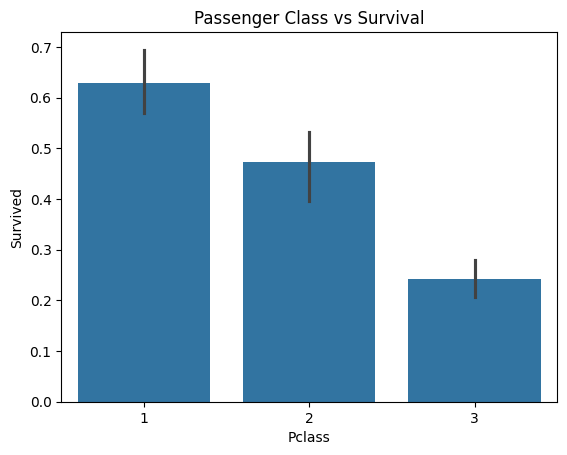

In [30]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Passenger Class vs Survival")
plt.show()

# Scatter Plot Analysis
Scatter plots are used to visualize the relationship between Age and Fare with respect to survival.

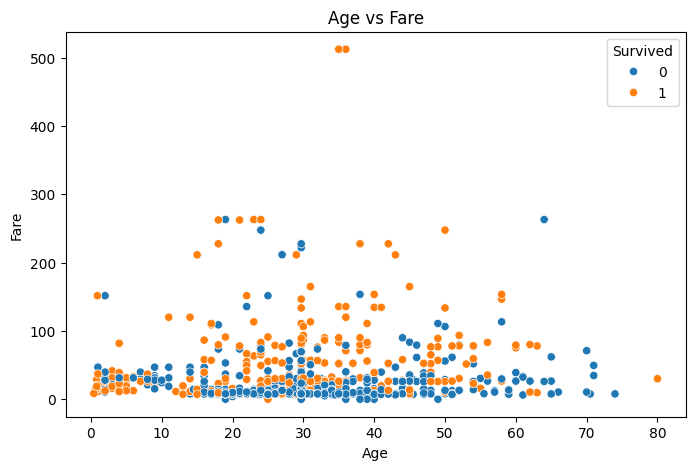

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title("Age vs Fare")
plt.show()

# Data Preprocessing
Data preprocessing techniques are applied to clean and prepare the dataset for machine learning algorithms.

In [32]:
imputer = SimpleImputer(strategy='mean')

df['Age'] = imputer.fit_transform(df[['Age']])

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Fare'] = df['Fare'].fillna(df['Fare'].mean())

# Removing Unnecessary Features
Irrelevant columns that do not contribute significantly to prediction are removed from the dataset.

In [33]:
df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1, inplace=True)

# Encoding Categorical Variables
Categorical features are converted into numerical format using label encoding techniques.

In [34]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])

df['Embarked'] = le.fit_transform(df['Embarked'])

# Feature and Target Selection
The independent features and target variable are separated for model training.

In [35]:
X = df.drop('Survived', axis=1)

y = df['Survived']

# Splitting Dataset into Training and Testing Data
The dataset is divided into training and testing sets to evaluate model performance on unseen data.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Building LightGBM Model
The LightGBM classification model is initialized and trained using the training dataset.

In [37]:
lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001335 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 195
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


# Evaluating LightGBM Model
The performance of the LightGBM model is evaluated using accuracy, precision, recall, and F1-score metrics.

In [38]:
print("LightGBM Accuracy :", accuracy_score(y_test, y_pred_lgbm))
print("Precision :", precision_score(y_test, y_pred_lgbm))
print("Recall :", recall_score(y_test, y_pred_lgbm))
print("F1 Score :", f1_score(y_test, y_pred_lgbm))

LightGBM Accuracy : 0.8212290502793296
Precision : 0.7837837837837838
Recall : 0.7837837837837838
F1 Score : 0.7837837837837838


# Building XGBoost Model
The XGBoost classification model is trained to predict passenger survival.

In [39]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

# Evaluating XGBoost Model
Performance metrics are calculated to evaluate the effectiveness of the XGBoost model.

In [40]:
print("XGBoost Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision :", precision_score(y_test, y_pred_xgb))
print("Recall :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

XGBoost Accuracy : 0.8100558659217877
Precision : 0.7702702702702703
Recall : 0.7702702702702703
F1 Score : 0.7702702702702703


# Confusion Matrix for LightGBM
The confusion matrix visualizes the classification performance of the LightGBM model.

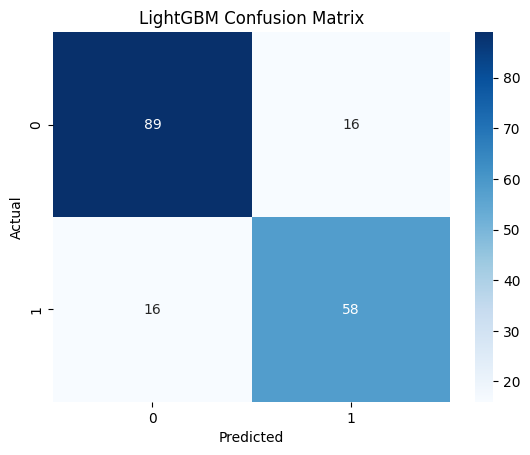

In [41]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues')
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Confusion Matrix for LightGBM
The confusion matrix visualizes the classification performance of the LightGBM model.

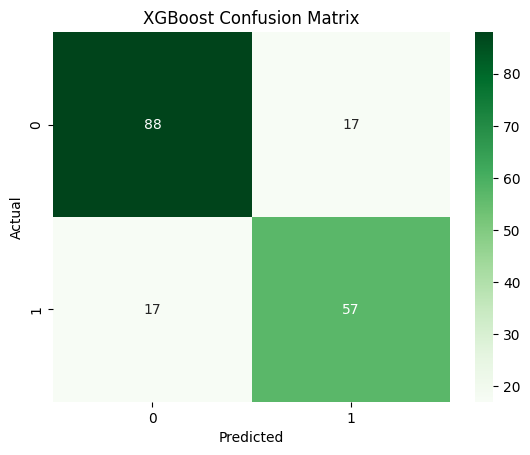

In [42]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Cross Validation for LightGBM
Cross-validation is performed to measure the consistency and reliability of the LightGBM model.

In [43]:
lgbm_cv = cross_val_score(lgbm, X, y, cv=5)

print("LightGBM Cross Validation Score :", lgbm_cv.mean())

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 203
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


# Cross Validation for XGBoost
Cross-validation is applied to evaluate the generalization performance of the XGBoost model.

In [44]:
xgb_cv = cross_val_score(xgb, X, y, cv=5)

print("XGBoost Cross Validation Score :", xgb_cv.mean())

XGBoost Cross Validation Score : 0.8159751428033394


# Hyperparameter Tuning for LightGBM
Grid Search Cross Validation is used to identify the optimal hyperparameters for the LightGBM model.

In [45]:
params_lgbm = {
    'n_estimators':[50,100],
    'max_depth':[3,5,7]
}

grid_lgbm = GridSearchCV(LGBMClassifier(), params_lgbm, cv=3)

grid_lgbm.fit(X_train, y_train)

print(grid_lgbm.best_params_)

[LightGBM] [Info] Number of positive: 178, number of negative: 296
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 162
[LightGBM] [Info] Number of data points in the train set: 474, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375527 -> initscore=-0.508576
[LightGBM] [Info] Start training from score -0.508576
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


# Hyperparameter Tuning for XGBoost
Hyperparameter tuning improves the performance of the XGBoost model by selecting the best parameters.

In [46]:
params_xgb = {
    'n_estimators':[50,100],
    'max_depth':[3,5,7]
}

grid_xgb = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
                        params_xgb,
                        cv=3)

grid_xgb.fit(X_train, y_train)

print(grid_xgb.best_params_)

{'max_depth': 3, 'n_estimators': 50}


# Comparative Performance Analysis
The performance of LightGBM and XGBoost models is compared using various evaluation metrics.

In [47]:
results = pd.DataFrame({
    'Model':['LightGBM','XGBoost'],
    'Accuracy':[accuracy_score(y_test, y_pred_lgbm),
                accuracy_score(y_test, y_pred_xgb)],

    'Precision':[precision_score(y_test, y_pred_lgbm),
                 precision_score(y_test, y_pred_xgb)],

    'Recall':[recall_score(y_test, y_pred_lgbm),
              recall_score(y_test, y_pred_xgb)],

    'F1 Score':[f1_score(y_test, y_pred_lgbm),
                f1_score(y_test, y_pred_xgb)]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,LightGBM,0.821229,0.783784,0.783784,0.783784
1,XGBoost,0.810056,0.770270,0.770270,0.770270


# Model Comparison Visualization
Bar charts are used to visually compare the performance metrics of both machine learning models.

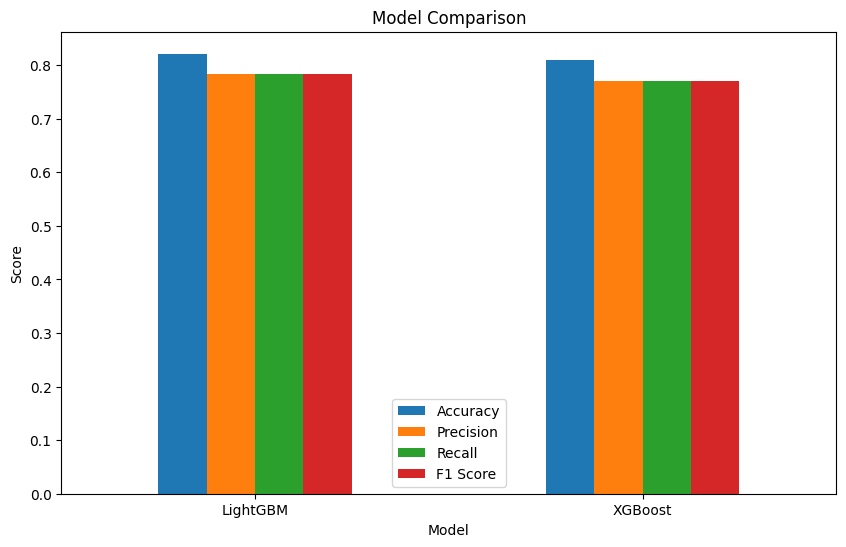

In [48]:
results.set_index('Model').plot(kind='bar', figsize=(10,6))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

# Conclusion

In this assignment, LightGBM and XGBoost algorithms were implemented on the Titanic dataset for survival prediction.

Both models produced high classification performance with strong accuracy, precision, recall, and F1-score values.

XGBoost generally provides highly accurate predictions but requires more computational resources, whereas LightGBM is faster and more memory efficient.

Cross-validation and hyperparameter tuning improved the reliability and performance of both models.

From the comparative analysis, the better-performing model can be selected based on accuracy, speed, and scalability requirements.

# Interview Questions and Answers

## 1. What is LightGBM?

LightGBM is a gradient boosting framework developed by Microsoft that is designed for fast and efficient machine learning.

## 2. What is XGBoost?

XGBoost is an optimized gradient boosting algorithm known for high performance and accuracy in machine learning tasks.

## 3. What is boosting?

Boosting is an ensemble learning technique that combines multiple weak learners to form a strong predictive model.

## 4. Why is preprocessing important in machine learning?

Preprocessing improves data quality by handling missing values, encoding categorical variables, and preparing the dataset for model training.

## 5. What is cross-validation?

Cross-validation is a technique used to evaluate machine learning models by dividing the dataset into multiple subsets.





## 6. What is hyperparameter tuning?

Hyperparameter tuning is the process of selecting the best parameters to improve machine learning model performance.

## 7. What is overfitting?

Overfitting occurs when a model performs very well on training data but poorly on unseen testing data.

## 8. What is the difference between LightGBM and XGBoost?

LightGBM is faster and more memory efficient, while XGBoost focuses more on accuracy and regularization.